In [19]:
from src.patient_data_dispatcher import PatientDataDispatcher
from src.core.enums import MileStone, DataFrequency, PatientDataType
from src.evaluation import Evaluation
from src.core.normaliser import Normaliser
from sklearn.preprocessing import MinMaxScaler
from src.core.data_transforms import Transform
from src.model import DMORandomForestRegressor

import numpy as np
import torch
import shap

In [2]:
K_FOLDS = 5
N_VISITS = 4

In [3]:
dmo_features = [
    "wb_all_sum",
    "walkdur_all_sum",
    "wbsteps_all_sum",
    "wbdur_all_avg",
    "wbdur_all_p90",
    "wbdur_all_var",
    "cadence_all_avg",
    "strdur_all_avg",
    "cadence_all_var",
    "strdur_all_var",
    "ws_1030_avg",
    "strlen_1030_avg",
    "wb_10_sum",
    "ws_10_p90",
    "wb_30_sum",
    "ws_30_avg",
    "strlen_30_avg",
    "cadence_30_avg",
    "strdur_30_avg",
    "ws_30_p90",
    "cadence_30_p90",
    "ws_30_var",
    "strlen_30_var",
    "wb_60_sum",
]

In [4]:
pdd = PatientDataDispatcher(
    "config/config.yaml",
    dmo_features,
    MileStone.ALL,
    data_frequency=DataFrequency.DAILY,
    physical_subset=True,
    #static_features=static_features
)
ids = list(set(pdd.metadata["Local.Participant"].to_list()))
dmo_data, dmo_labels = pdd.get_patient_data(PatientDataType.MILESTONE, ids=ids)

In [5]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# perform impute on a visit by visit basis, as some visits are completely missing
imputer = IterativeImputer(missing_values=-1, tol=1e-2, keep_empty_features=True)
patients, visits, features, days = dmo_data.shape

for p in range(patients):
    for v in range(visits):
        visit_data = dmo_data[p, v]

        if (visit_data == -1).all():
            continue

        dmo_data[p, v] = torch.from_numpy(imputer.fit_transform(visit_data)).to(dtype=torch.float64)

/home/gwilym-rutherford/Documents/Year 3 Tuos/dissertation/Workspace/Experiment 1/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [6]:
dmo_data, dmo_labels = Transform.get_patient_visits(dmo_data, dmo_labels, n_visits=N_VISITS)

In [7]:
# remove missing labels
patient_indexs = []
patient, visit, day, features = dmo_data.shape
for p in range(patient):
    all_visits = True
    for v in range(visit):
        data = dmo_data[p, v]
        label = dmo_labels[p, v]
        
        if (data == -1.0).any() or label == -1.0:
            all_visits = False

    if all_visits:
        patient_indexs.append(p)

dmo_data = dmo_data[patient_indexs]
dmo_labels = dmo_labels[patient_indexs]

In [8]:
dmo_data.shape

torch.Size([428, 4, 7, 24])

In [9]:
dmo_data = dmo_data.mean(axis=2)

In [30]:
dmo_data.shape

torch.Size([428, 4, 24])

In [10]:
dmo_labels.shape

torch.Size([428, 4, 1])

In [11]:
current_features = dmo_data[:, 1:, :]
prev_labels = dmo_labels[:, :-1, :]
X_tensor = torch.cat((current_features, prev_labels), dim=2)
y_tensor = dmo_labels[:, -1, :]
input_data = X_tensor.flatten(start_dim=1, end_dim=2)
label_data = y_tensor.reshape(-1)

In [12]:
input_data[0]

tensor([3.1857e+02, 5.4857e+01, 4.4901e+03, 7.1000e+00, 1.8171e+01, 1.2157e+02,
        8.8000e+01, 1.2729e+00, 1.2143e+01, 2.0571e+01, 6.2429e-01, 8.7571e+01,
        9.0571e+01, 8.1571e-01, 1.0000e+01, 8.5429e-01, 1.1343e+02, 8.7571e+01,
        1.2343e+00, 1.1529e+00, 9.3714e+01, 2.9286e+01, 2.5714e+01, 2.4286e+00,
        7.0000e+00, 2.6443e+02, 4.2857e+01, 3.3640e+03, 7.1000e+00, 1.6786e+01,
        1.1486e+02, 8.8143e+01, 1.3129e+00, 1.2143e+01, 1.9714e+01, 6.0286e-01,
        8.5143e+01, 7.6429e+01, 7.2571e-01, 7.0000e+00, 6.9857e-01, 9.5000e+01,
        8.6714e+01, 1.3057e+00, 8.7000e-01, 9.1714e+01, 1.9143e+01, 1.8714e+01,
        1.1429e+00, 1.5000e+01, 2.3229e+02, 3.4000e+01, 2.8866e+03, 6.7571e+00,
        1.5857e+01, 8.2143e+01, 8.8429e+01, 1.2271e+00, 1.2571e+01, 2.1857e+01,
        5.9429e-01, 8.2143e+01, 5.9571e+01, 8.5857e-01, 4.2857e+00, 8.7805e-01,
        1.0954e+02, 9.1640e+01, 1.1320e+00, 1.1349e+00, 9.8252e+01, 3.1094e+01,
        2.5784e+01, 5.7143e-01, 2.3000e+

In [13]:
label_data[0]

tensor(13)

In [31]:
input_data.shape

torch.Size([428, 75])

In [14]:
# shuffle
patients, *other = input_data.shape
generator = torch.Generator()
generator.manual_seed(1234)
random_permutation = torch.randperm(patients, generator=generator)

input_data = input_data[random_permutation]
label_data = label_data[random_permutation]

In [21]:
fatigue_input_split = torch.tensor_split(input_data, K_FOLDS)
fatigue_label_split = torch.tensor_split(label_data, K_FOLDS)

prediction_arr = []
actual_arr = []
shap_values = []
test_inputs = []
baseline_values = []

for split_i in range(K_FOLDS):
    test_label = fatigue_label_split[split_i]
    test_data = fatigue_input_split[split_i]

    train_label = torch.cat(
        [fatigue_label_split[i] for i in range(0, K_FOLDS) if i != split_i]
    )
    train_data = torch.cat(
        [fatigue_input_split[i] for i in range(0, K_FOLDS) if i != split_i]
    )
    
    rf_model = DMORandomForestRegressor(n_trees=500)

    rf_model.train(train_data, train_label)
    score = rf_model.score(test_data, test_label)
    print(score)
    
    prediction = torch.tensor(rf_model.predict(test_data))
    # prediction = (prediction * physical_subset_max)
    
    actual = test_label
    # actual = (test_label * physical_subset_max)
    
    prediction_arr.append(prediction)
    actual_arr.append(actual)
    
    sklearn_rf_model = rf_model.random_forest
    
    test_input_numpy = np.array(test_data)
    explainer = shap.TreeExplainer(sklearn_rf_model)
    shap_value = explainer.shap_values(test_input_numpy)
    shap_values.append(shap_value)
    test_inputs.append(test_data)
    baseline_values.append(explainer.expected_value)
    

0.6613014112450037


/tmp/ipykernel_106610/3831114478.py:38: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  test_input_numpy = np.array(test_data)


0.6180808760593083


/tmp/ipykernel_106610/3831114478.py:38: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  test_input_numpy = np.array(test_data)


0.6921657729306268


/tmp/ipykernel_106610/3831114478.py:38: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  test_input_numpy = np.array(test_data)


0.59173203285025


/tmp/ipykernel_106610/3831114478.py:38: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  test_input_numpy = np.array(test_data)


0.6798446496671979


/tmp/ipykernel_106610/3831114478.py:38: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  test_input_numpy = np.array(test_data)


In [22]:
prediction = torch.cat(prediction_arr)
actual = torch.cat(actual_arr)

{'accuracy': 0.02336448598130841, 'Mean Squared Error': 24.684019088745117, 'Mean Absolute Error': 3.8775887489318848, 'R^2': 0.6512231914607165}


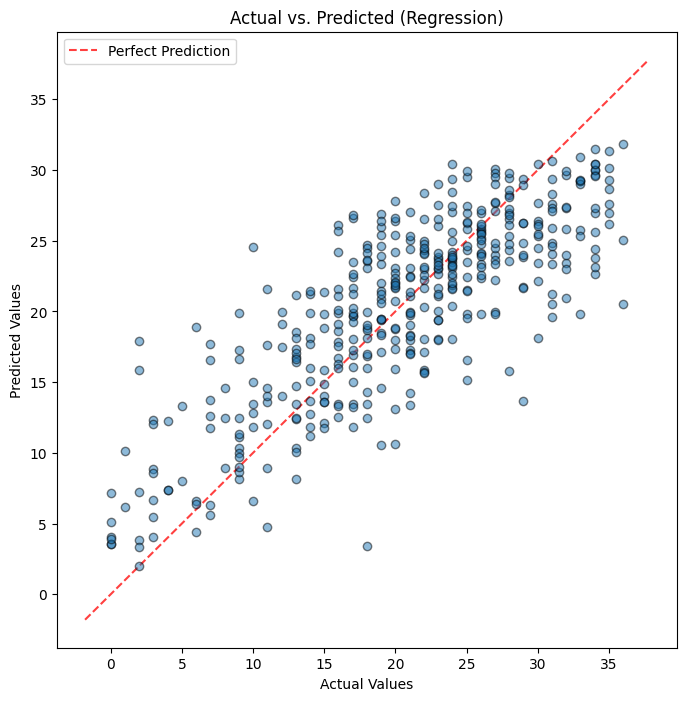

In [23]:
evaluation = Evaluation(prediction, actual)
print(evaluation.compute_all_metrics())
evaluation.evaluation_plot().show()

In [24]:
import numpy as np

shap_values = np.concat(shap_values, axis=0)
test_inputs = np.concat(test_inputs, axis=0)
baseline_labels = np.mean(baseline_values)

In [32]:
shap_values = shap_values.reshape(-1, 3, 25)
shap_values = shap_values.mean(axis=1)
shap_values.shape

(428, 25)

In [33]:
test_inputs = test_inputs.reshape(-1, 3, 25)
test_inputs = test_inputs.mean(axis=1)
test_inputs.shape

(428, 25)

In [27]:
dmo_features

['wb_all_sum',
 'walkdur_all_sum',
 'wbsteps_all_sum',
 'wbdur_all_avg',
 'wbdur_all_p90',
 'wbdur_all_var',
 'cadence_all_avg',
 'strdur_all_avg',
 'cadence_all_var',
 'strdur_all_var',
 'ws_1030_avg',
 'strlen_1030_avg',
 'wb_10_sum',
 'ws_10_p90',
 'wb_30_sum',
 'ws_30_avg',
 'strlen_30_avg',
 'cadence_30_avg',
 'strdur_30_avg',
 'ws_30_p90',
 'cadence_30_p90',
 'ws_30_var',
 'strlen_30_var',
 'wb_60_sum',
 'prev_MFIS']

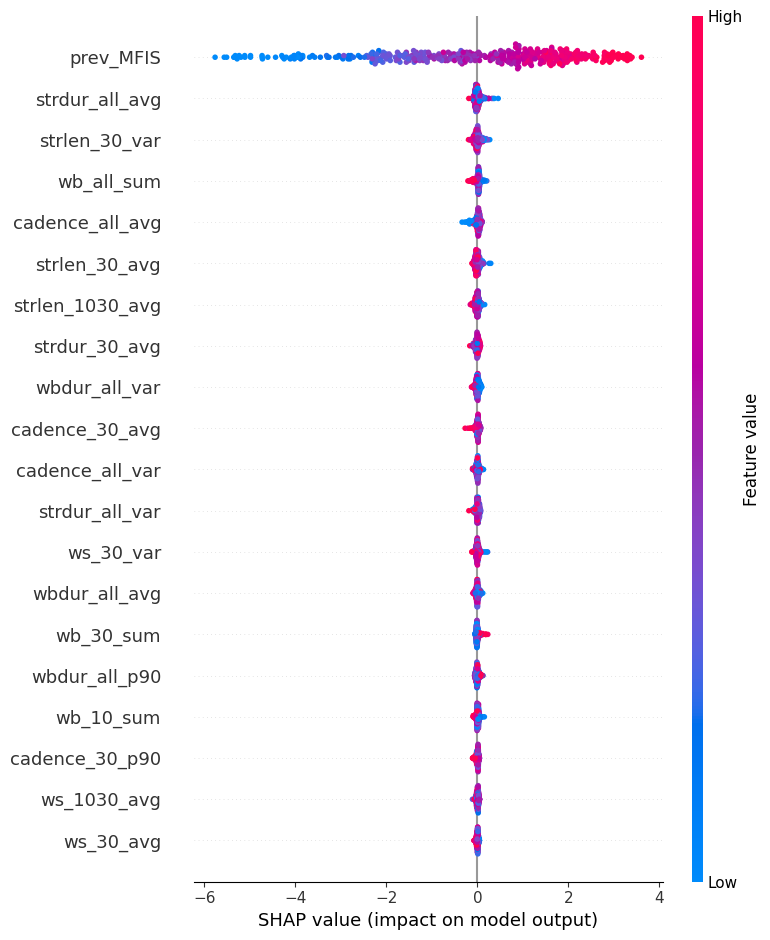

In [34]:
import shap

#dmo_features.append("prev_MFIS")

shap.summary_plot(
    shap_values,
    test_inputs,
    feature_names=dmo_features,
)

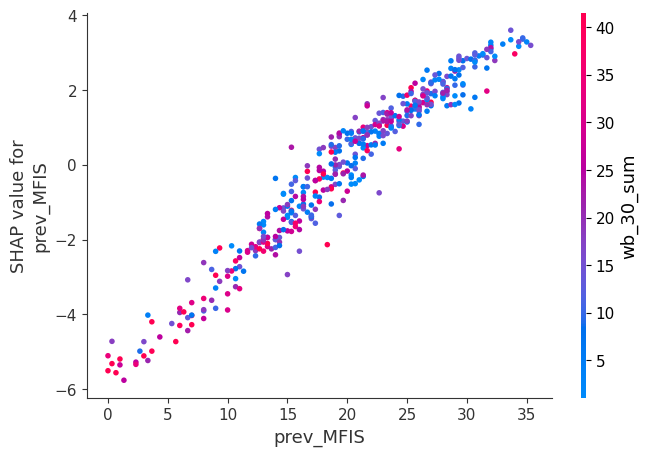

In [35]:
shap.dependence_plot(
    "prev_MFIS", 
    shap_values, 
    test_inputs, 
    feature_names=dmo_features
)